In [1]:
# Figure 3. No mites, chi = 600 and sigma = 300

import numpy as np
import matplotlib.pyplot as plt

from symengine import exp, cos, pi, Abs
from jitcdde import y, t, jitcdde

# Parameters
phi_B     = 0.018
phi_H     = 0.007
epsilon_B = 2000
b         = 500
k         = 5000
a         = 500     
tau       = 12
gamma_B   = 0.003
gamma_H   = 0.05
chi       = 600
sigma     = 300
theta     = 105
kappa     = 1/9

# Initial Conditions
B0 = 5000
H0 = 10000
f0 = 1000

# Simulation Setuo
STARTTIME = 0
STOPTIME  = 730
DT        = 0.02
eps       = 1e-6

def Phi_numeric(tt):
    return chi + sigma * np.cos(2*np.pi*(tt - theta)/365)

# Helpers 
def pos(x):
    # symbolic max(x,0)
    return (x + Abs(x))/2

# States
IDX_B = 0
IDX_H = 1
IDX_f = 2

B = y(IDX_B)
H = y(IDX_H)
f = y(IDX_f)

B_tau = y(IDX_B, t - tau)

# Euler-like nonnegativity inside RHS
B_pos     = pos(B)
H_pos     = pos(H)
f_pos     = pos(f)
B_tau_pos = pos(B_tau)

# S(H,f)
S = (f_pos / (b + f_pos)) * (H_pos / (k + H_pos))

# No mites -> integral term is 0 
exp_B = exp(-gamma_B * tau)

# Seasonal Phi(t)
Phi = chi + sigma * cos(2*pi*(t - theta)/365)

# DDE MODEL
dB = epsilon_B * S - gamma_B * B_pos - kappa * exp_B * B_tau_pos
dH = kappa * exp_B * B_tau_pos - gamma_H * H_pos
df = Phi * (H_pos / (k + H_pos)) - phi_B * B_pos - phi_H * H_pos

# EXTRA: Euler-like "projection" so the *state* doesn't drift negative (affects delay history)
lam = 120  # strength of push-back to 0 when negative (tune 80–150 if needed)
dB = dB + lam * (B_pos - B)
dH = dH + lam * (H_pos - H)
df = df + lam * (f_pos - f)

DDE = jitcdde([dB, dH, df])

# Constant history for s<=0
def history(s):
    return [B0, H0, f0]

DDE.past_from_function(history)
DDE.step_on_discontinuities()

# Solver settings: keep max_step ~ DT to mimic Euler stepping near kinks
DDE.set_integration_parameters(atol=1e-8,  rtol=1e-6, min_step=1e-12, max_step=DT, first_step=DT)

# INTEGRATE 
# avoid backward integration warning
t0 = float(DDE.t)
start = max(STARTTIME + eps, t0)

times = np.arange(start, STOPTIME + DT/2, DT)
times_plot = np.concatenate(([STARTTIME], times))

sol = np.zeros((len(times_plot), 3), dtype=float)
sol[0, :] = np.array([B0, H0, f0], dtype=float)

for i, tt in enumerate(times, start=1):
    sol[i, :] = DDE.integrate(float(tt))

B_values = sol[:, IDX_B]
H_values = sol[:, IDX_H]
f_values = sol[:, IDX_f]

# Plotting Phi
Phi_values = Phi_numeric(times_plot)

# EXPORT RESULTS: RUN 1 
times_plot_1 = times_plot.copy()

B_1   = B_values.copy()
H_1   = H_values.copy()
f_1   = f_values.copy()

Phi_1 = Phi_values.copy()

Generating, compiling, and loading C code.


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


Using default integration parameters.


In [2]:
# Figure 3. No mites, chi = 500 and sigma = 400

import numpy as np
import matplotlib.pyplot as plt

from symengine import exp, cos, pi, Abs
from jitcdde import y, t, jitcdde

# Parameters
phi_B     = 0.018
phi_H     = 0.007
epsilon_B = 2000
b         = 500
k         = 5000
a         = 500     
tau       = 12
gamma_B   = 0.003
gamma_H   = 0.05
chi       = 500
sigma     = 400
theta     = 105
kappa     = 1/9

# Initial Conditions
B0 = 5000
H0 = 10000
f0 = 1000

# Simulation Setuo
STARTTIME = 0
STOPTIME  = 730
DT        = 0.02
eps       = 1e-6

def Phi_numeric(tt):
    return chi + sigma * np.cos(2*np.pi*(tt - theta)/365)

# Helpers 
def pos(x):
    # symbolic max(x,0)
    return (x + Abs(x))/2

# States
IDX_B = 0
IDX_H = 1
IDX_f = 2

B = y(IDX_B)
H = y(IDX_H)
f = y(IDX_f)

B_tau = y(IDX_B, t - tau)

# Euler-like nonnegativity inside RHS
B_pos     = pos(B)
H_pos     = pos(H)
f_pos     = pos(f)
B_tau_pos = pos(B_tau)

# S(H,f)
S = (f_pos / (b + f_pos)) * (H_pos / (k + H_pos))

# No mites -> integral term is 0 
exp_B = exp(-gamma_B * tau)

# Seasonal Phi(t)
Phi = chi + sigma * cos(2*pi*(t - theta)/365)

# DDE MODEL
dB = epsilon_B * S - gamma_B * B_pos - kappa * exp_B * B_tau_pos
dH = kappa * exp_B * B_tau_pos - gamma_H * H_pos
df = Phi * (H_pos / (k + H_pos)) - phi_B * B_pos - phi_H * H_pos

# EXTRA: Euler-like "projection" so the *state* doesn't drift negative (affects delay history)
lam = 120  # strength of push-back to 0 when negative (tune 80–150 if needed)
dB = dB + lam * (B_pos - B)
dH = dH + lam * (H_pos - H)
df = df + lam * (f_pos - f)

DDE = jitcdde([dB, dH, df])

# Constant history for s<=0
def history(s):
    return [B0, H0, f0]

DDE.past_from_function(history)
DDE.step_on_discontinuities()

# Solver settings: keep max_step ~ DT to mimic Euler stepping near kinks
DDE.set_integration_parameters(atol=1e-8,  rtol=1e-6, min_step=1e-12, max_step=DT, first_step=DT)

# INTEGRATE 
# avoid backward integration warning
t0 = float(DDE.t)
start = max(STARTTIME + eps, t0)

times = np.arange(start, STOPTIME + DT/2, DT)
times_plot = np.concatenate(([STARTTIME], times))

sol = np.zeros((len(times_plot), 3), dtype=float)
sol[0, :] = np.array([B0, H0, f0], dtype=float)

for i, tt in enumerate(times, start=1):
    sol[i, :] = DDE.integrate(float(tt))

B_values = sol[:, IDX_B]
H_values = sol[:, IDX_H]
f_values = sol[:, IDX_f]

# Plotting Phi
Phi_values = Phi_numeric(times_plot)

# EXPORT RESULTS: RUN 2 
times_plot_2 = times_plot.copy()

B_2   = B_values.copy()
H_2   = H_values.copy()
f_2   = f_values.copy()
Phi_2 = Phi_values.copy()

B_2 = np.maximum(B_2, 0)
H_2 = np.maximum(H_2, 0)
f_2 = np.maximum(f_2, 0)


Generating, compiling, and loading C code.


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


Using default integration parameters.


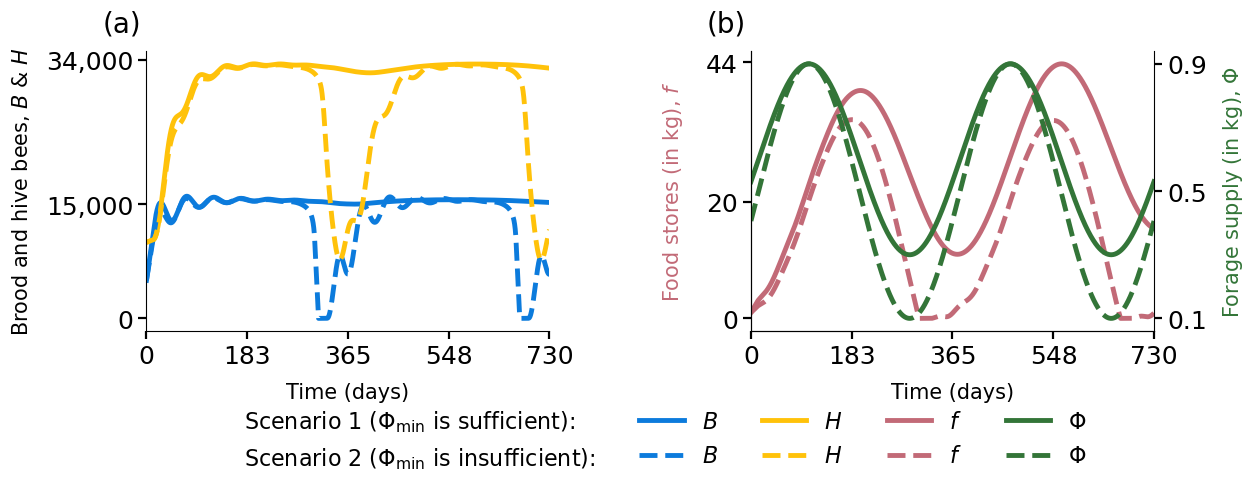

In [3]:
# Figure 3. COMBINED PLOTS: RUN 1 vs RUN 2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

B_color   = (12/255, 123/255, 220/255)
H_color   = (255/255, 194/255, 10/255)
f_color   = (194/255, 106/255, 119/255)
Phi_color = (51/255, 117/255, 56/255)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,4), sharex=True)

# (a) B and H 
l1, = ax1.plot(times_plot_1, B_1, color=B_color, linewidth=3.5, label='$B$')
l2, = ax1.plot(times_plot_1, H_1, color=H_color, linewidth=3.5, label='$H$')
l1b, = ax1.plot(times_plot_2, np.maximum(B_2, 0), color=B_color, linewidth=3.5, linestyle='--', label='$B$')
l2b, = ax1.plot(times_plot_2, H_2, color=H_color, linewidth=3.5, linestyle='--', label='$H$')

ax1.set_xlabel("Time (days)", color='black', fontsize=15, labelpad=10, ha='center')
ax1.set_ylabel("Brood and hive bees, $B$ & $H$", color='black', fontsize=15, labelpad=10, ha='center')
ax1.tick_params(axis='x', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax1.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax1.set_xlim(STARTTIME, STOPTIME)
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_yticks([34000, 15000, 0])
ax1.set_yticklabels(['34,000', '15,000', '0'])
ax1.set_xticks([0, 183, 365, 548, STOPTIME])
ax1.text(-0.11, 1.15, "(a)", transform=ax1.transAxes, color='black', fontsize=20, va='top', ha='left')

# (b) f and Phi
l3, = ax2.plot(times_plot_1, f_1, color=f_color, linewidth=3.5, label='$f$')
l3b, = ax2.plot(times_plot_2, f_2, color=f_color, linewidth=3.5, linestyle='--', label='$f$')

ax2.set_xlabel("Time (days)", color='black', fontsize=15, labelpad=10, ha='center')
ax2.set_ylabel("Food stores (in kg), $f$", color=f_color , fontsize=15, labelpad=15, ha='center')
ax2.tick_params(axis='x', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax2.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax2.set_xlim(STARTTIME, STOPTIME)
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_yticks([44000, 20000, 0])
ax2.set_yticklabels(['44', '20', '0'])
ax2.set_xticks([0, 183, 365, 548, STOPTIME])

ax2b = ax2.twinx()
l4, = ax2b.plot(times_plot_1, Phi_1, color=Phi_color, linewidth=3.5, label='$\\Phi$')
l4b, = ax2b.plot(times_plot_2, Phi_2, linestyle='--', color=Phi_color, linewidth=3.5, label='$\\Phi$')
ax2b.set_ylabel("Forage supply (in kg), $\\Phi$", color=Phi_color, fontsize=15, labelpad=10, ha='center')
ax2b.tick_params(axis='y', which='major', labelsize=18, width=1.6, length=6, colors='black')
ax2b.spines['top'].set_visible(False)
ax2b.set_yticks([900, 500, 100])
ax2b.set_yticklabels(['0.9', '0.5', '0.1'])

ax2.text(-0.11, 1.15, "(b)", transform=ax2.transAxes, color='black', fontsize=20, va='top', ha='left')

txt_sufficient = Line2D([], [], linestyle='None')
txt_insufficient = Line2D([], [], linestyle='None')

handles = [txt_sufficient, txt_sufficient, l1, l1b, l2, l2b, l3, l3b, l4, l4b]
labels  = [r'Scenario 1 ($\Phi_{\min}$ is sufficient):', r'Scenario 2 ($\Phi_{\min}$ is insufficient):', '$B$', '$B$', '$H$', '$H$',  
           '$f$', '$f$', '$\\Phi$', '$\\Phi$']

fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=16, frameon=False, bbox_to_anchor=(0.5, -0.22))
plt.subplots_adjust(bottom=0.18, wspace=0.5)
plt.savefig("no mites.png", dpi=300, bbox_inches='tight')
plt.show()


In [25]:
import numpy as np
import pandas as pd

# STEP 1: Restrict to t <= 365 and find H minimum (Scenario 2)
mask_365 = times_plot_2 <= 365

H2_cut = H_2[mask_365]
times_cut = times_plot_2[mask_365]

if H2_cut.size == 0:
    raise ValueError("No data points found for t <= 365.")

idx_Hmin = np.argmin(H2_cut)
H2_min = H2_cut[idx_Hmin]
t_Hmin = times_cut[idx_Hmin]

print(f"\nMinimum hive bees in Scenario 2 (t ≤ 365): {H2_min:.2f}")
print(f"Occurred at t = {t_Hmin:.2f}")

# STEP 2: Search AFTER H_min time until end of simulation
tol = 0.05  # tolerance for "approximately twice"

idx_global_start = np.where(times_plot_2 >= t_Hmin)[0][0]

recovery_time = None
recovery_state = None

for i in range(idx_global_start, len(times_plot_2)):
    B_val = B_2[i]
    H_val = H_2[i]

    # avoid division by zero
    if B_val != 0:
        ratio = H_val / B_val
        if abs(ratio - 2) <= tol:
            recovery_time = times_plot_2[i]
            recovery_state = (B_val, H_val, f_2[i], Phi_2[i], ratio)
            break

# STEP 3: Output
if recovery_time is not None:
    B_rec, H_rec, f_rec, Phi_rec, ratio_rec = recovery_state

    recovery_df = pd.DataFrame({
        "Time": [recovery_time],
        "Brood (B)": [B_rec],
        "Hive Bees (H)": [H_rec],
        "Food (f)": [f_rec],
        "Forage (Phi)": [Phi_rec],
        "H/B ratio": [ratio_rec]
    })

    print("\nRecovery detected (Scenario 2)")
    print(recovery_df.round(2).to_string(index=False))
else:
    print("\nNo recovery (H ≈ 2B) detected after H_min within simulation window.")


Minimum hive bees in Scenario 2 (t ≤ 365): 7742.59
Occurred at t = 350.28

Recovery detected (Scenario 2)
 Time  Brood (B)  Hive Bees (H)  Food (f)  Forage (Phi)  H/B ratio
364.1    5847.14       11403.88    797.79        400.19       1.95
